In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
df=pd.read_csv("/content/economic_index.csv", index_col=0)
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [15]:
df.isnull().sum()

,0
year,0
month,0
interest_rate,0
unemployment_rate,0
index_price,0


In [16]:
df.describe()

,year,month,interest_rate,unemployment_rate,index_price
count,24.000000,24.000000,24.000000,24.00000,24.000000
mean,2016.500000,6.500000,2.072917,5.77500,1070.083333
std,0.510754,3.526299,0.349527,0.33002,210.735341
min,2016.000000,1.000000,1.750000,5.30000,704.000000
25%,2016.000000,3.750000,1.750000,5.50000,928.250000
50%,2016.500000,6.500000,2.000000,5.85000,1061.000000
75%,2017.000000,9.250000,2.500000,6.10000,1239.000000
max,2017.000000,12.000000,2.750000,6.20000,1464.000000


In [17]:
df.corr()

,year,month,interest_rate,unemployment_rate,index_price
year,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


In [19]:
df.iloc[:,0:2]

,year,month
0,2017,12
1,2017,11
2,2017,10
3,2017,9
4,2017,8
5,2017,7
6,2017,6
7,2017,5
8,2017,4
9,2017,3


In [21]:
df.drop(df.iloc[:,:2],axis=1,inplace=True)

In [22]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

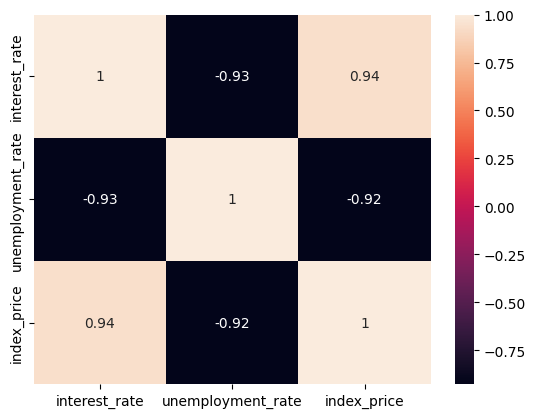

In [23]:
sns.heatmap(df.corr(),annot=True)

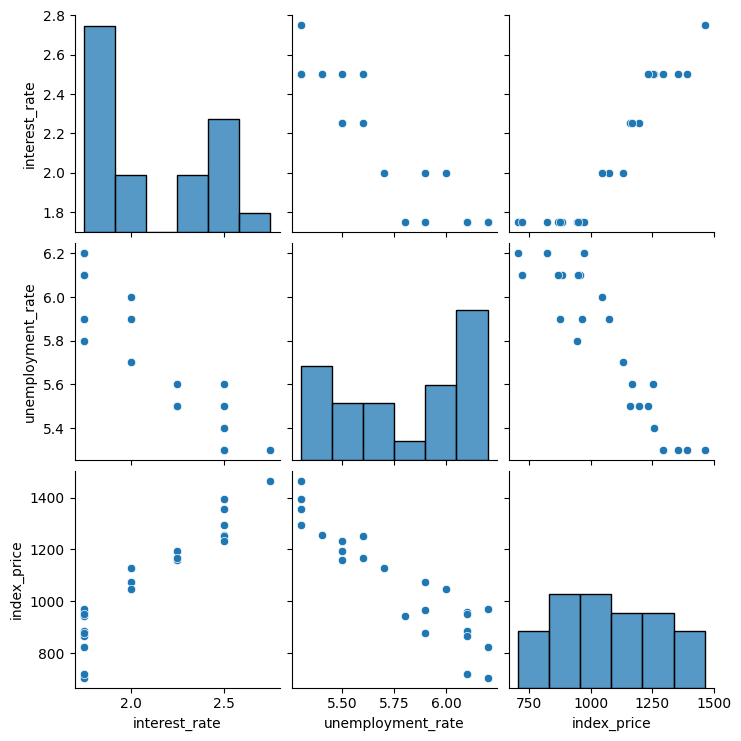

In [24]:
sns.pairplot(df)

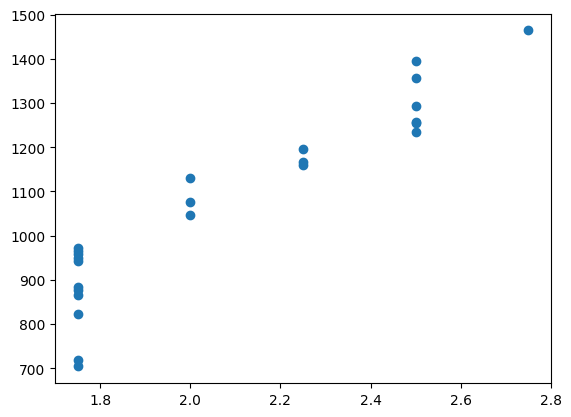

In [27]:
plt.scatter(df["interest_rate"],df["index_price"])
plt.show()

<Axes: ylabel='Count'>

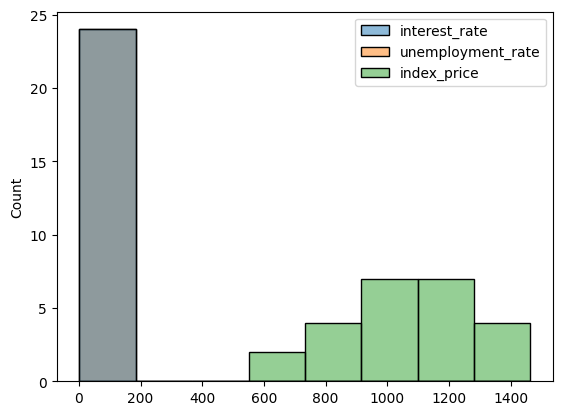

In [30]:
sns.histplot(df)

In [32]:
##independent and dependent features
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [33]:

# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [41]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)
## cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',
                                cv=3)

In [42]:
np.mean(validation_score)

-5914.828180162386

In [43]:

## prediction
y_pred=regression.predict(X_test)

In [44]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [45]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.7591371539010257
0.5985619231683761


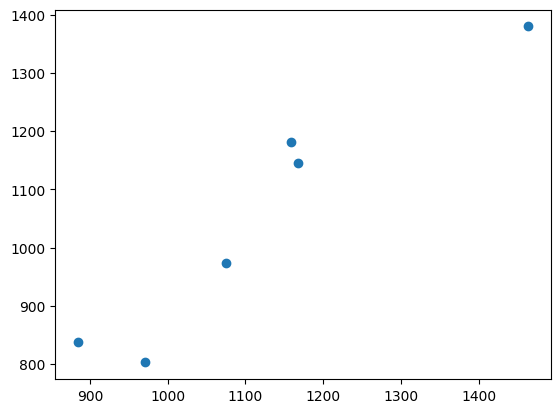

In [46]:
plt.scatter(y_test,y_pred)

In [47]:
residuals=y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


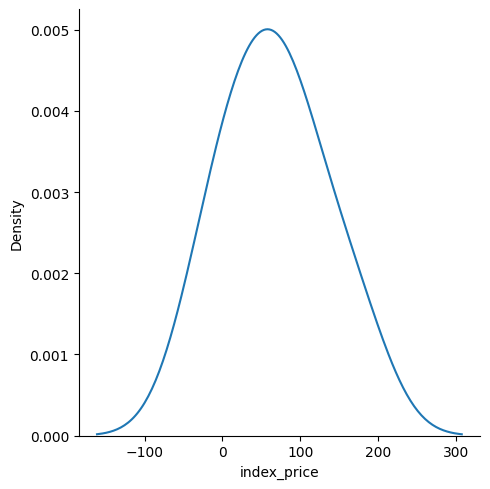

In [48]:
## Plot this residuals
sns.displot(residuals,kind='kde')

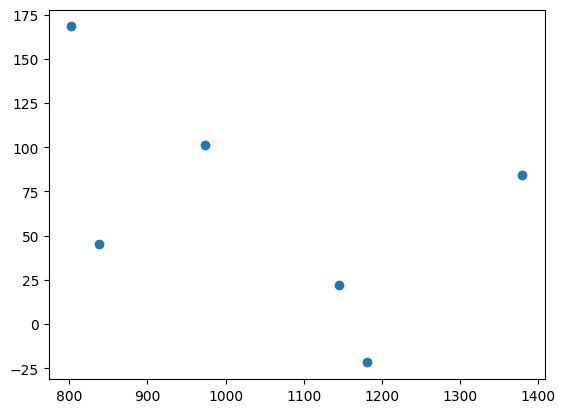

In [49]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [50]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [51]:
model.summary()

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 11 Nov 2024   Prob (F-statistic):                       0.754
Time:                        14:59:13   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
print(regression.coef_)

[  88.27275507 -116.25716066]
